
--- Outlier Report for Weather Table ---
Column: temp_max
   - Outliers Count: 54 (1.40%)
   - Normal Range: [-9.85 to 40.95]
   - Min/Max in Data: -31.0 / 38.5
Column: temp_min
   - Outliers Count: 70 (1.82%)
   - Normal Range: [-15.40 to 30.20]
   - Min/Max in Data: -35.1 / 27.1
Column: precipitation
   - Outliers Count: 578 (15.01%)
   - Normal Range: [-2.40 to 4.00]
   - Min/Max in Data: 0.0 / 69.2
Column: wind_speed
   - Outliers Count: 39 (1.01%)
   - Normal Range: [-5.95 to 39.25]
   - Min/Max in Data: 3.1 / 57.7

--- Outlier Report for Flights Table ---
Column: Departure Delay
   - Outliers Count: 422 (5.27%)
   - Normal Range: [-20.00 to 44.00]
   - Min/Max in Data: -975 / 634
Column: Arrival Delay
   - Outliers Count: 580 (7.24%)
   - Normal Range: [-56.50 to 43.50]
   - Min/Max in Data: -1014 / 634


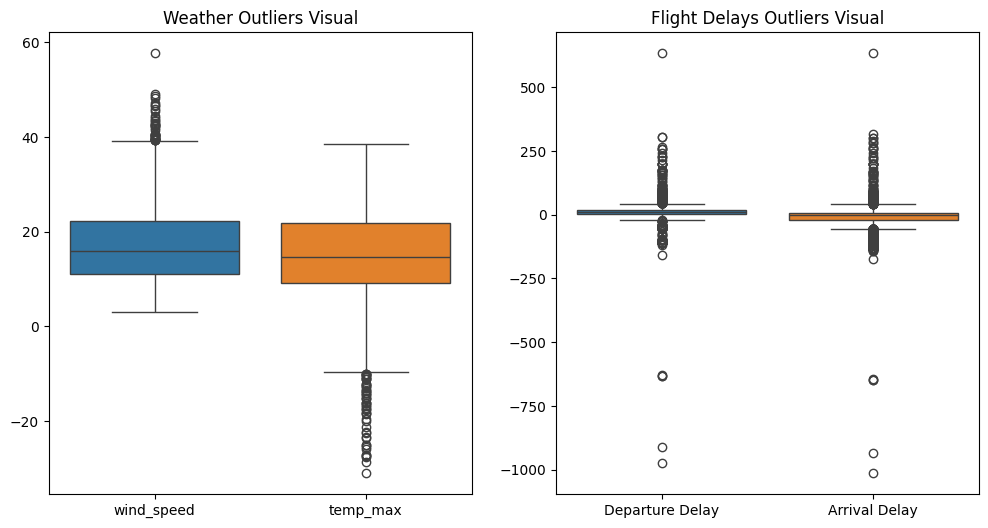

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
weather = pd.read_csv('/content/Weather_Clean_2026_Ready.csv')
flights = pd.read_csv('/content/Final Aviation Cleaning.csv')

def detect_outliers_report(df, table_name, columns):
    print(f"\n--- Outlier Report for {table_name} ---")
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        percentage = (outlier_count / len(df)) * 100

        print(f"Column: {col}")
        print(f"   - Outliers Count: {outlier_count} ({percentage:.2f}%)")
        print(f"   - Normal Range: [{lower_bound:.2f} to {upper_bound:.2f}]")
        print(f"   - Min/Max in Data: {df[col].min()} / {df[col].max()}")

weather_cols = ['temp_max', 'temp_min', 'precipitation', 'wind_speed']
detect_outliers_report(weather, "Weather Table", weather_cols)

flight_cols = ['Departure Delay', 'Arrival Delay']

detect_outliers_report(flights, "Flights Table", flight_cols)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=weather[['wind_speed', 'temp_max']])
plt.title('Weather Outliers Visual')

plt.subplot(1, 2, 2)
sns.boxplot(data=flights[['Departure Delay', 'Arrival Delay']])
plt.title('Flight Delays Outliers Visual')

plt.show()
